In [1]:
import numpy as np
import mpmath
import matplotlib.pyplot as plt
import pygridsynth as gridsynth

from bloqade import squin, tsim
from bloqade.cirq_utils import emit_circuit
import cirq

from bloqade.pyqrack import StackMemorySimulator

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
def show_circuit(squin_kernel):
    @squin.kernel
    def _to_visualize():
        _ = squin_kernel()

    return tsim.Circuit(_to_visualize).diagram(height=400)

In [3]:
@squin.kernel
def t_gate_teleportation(psi, magic_state):
    squin.h(magic_state[0])
    squin.t(magic_state[0])

    squin.cx(psi[0], magic_state[0])

    bit = squin.measure(magic_state[0])

    if bit == 1:
        squin.s(psi[0])
    
    return psi

In [4]:
@squin.kernel
def bell_state():
    q = squin.qalloc(2)
    squin.h(q[0])
    squin.cx(q[0],q[1])
    return q

@squin.kernel
def test_t_gate_teleportation():
    bell = bell_state()
    ancilla = squin.qalloc(1)
    bell = t_gate_teleportation(bell, ancilla)
    squin.t_adj(bell[1])
    return bell

bell_simulator = StackMemorySimulator(min_qubits=2)
bell_task = bell_simulator.task(bell_state)
bell = bell_task.run()
rho_bell = StackMemorySimulator.reduced_density_matrix(bell)

teleport_simulator = StackMemorySimulator(min_qubits=3)
teleport_task = teleport_simulator.task(test_t_gate_teleportation)
psi = teleport_task.run()
rho_psi = StackMemorySimulator.reduced_density_matrix(psi)

print("Density matrix of bell:")
print(rho_bell)
print()
print("Density matrix of psi:")
print(rho_psi)
print()
print("Do the two states match?", np.allclose(rho_bell, rho_psi))

Density matrix of bell:
[[0.50000001-0.j 0.        +0.j 0.        +0.j 0.50000001+0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j]
 [0.50000001-0.j 0.        +0.j 0.        +0.j 0.50000001-0.j]]

Density matrix of psi:
[[0.50000005+0.j         0.        +0.j         0.        +0.j
  0.50000008+0.00000003j]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.50000008-0.00000003j 0.        +0.j         0.        +0.j
  0.50000011+0.j        ]]

Do the two states match? True


In [5]:
import json

gridsynth_results = {}

with open("gridsynth_results.json", "r") as f:
    loaded_data = json.load(f)
    for k, v in loaded_data.items():
        gridsynth_results[eval(k)] = v

print("Loaded Gridsynth results:")
for key, value in gridsynth_results.items():
    print(f"n={key[0]}, eps={key[1]}: {value}")

Loaded Gridsynth results:
n=3, eps=0.1: SHTSHTHTSHTSHTSHTHTSHTHTSHTSHTSHTHTSHTSSWWWWW
n=3, eps=0.01: HTHTSHTHTSHTSHTHTHTSHTSHTHTHTSHTSHTSHTHTSHTHTSHSSW
n=3, eps=0.001: HTSHTSHTSHTHTHTHTHTHTHTSHTHTHTSHTSHTHTSHTSHTHTSHTSHTSHTSHTHTSHTSHTSHTHTHTHTHTSHTHTHTHXSSWWWWW
n=3, eps=0.0001: HTHTHTSHTSHTHTHTHTHTSHTSHTHTHTHTHTSHTHTHTHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTHTSHTSHTHTSHTSW
n=3, eps=0.00001: HTSHTHTHTSHTSHTSHTSHTHTSHTSHTSHTHTSHTHTSHTHTHTSHTSHTSHTHTSHTHTSHTHTHTHTHTHTHTSHTHTSHTHTHTSHTSHTHTSHTSHTSHTSHTHTHTHTSHTSHTSHTHTHSSS
n=3, eps=0.000001: HTHTSHTHTHTHTSHTSHTHTSHTHTSHTSHTHTSHTSHTHTHTSHTHTSHTHTHTHTSHTHTHTSHTSHTHTSHTHTSHTHTSHTHTSHTHTHTHTHTSHTHTSHTSHTHTHTSHTSHTSHTHTHTHTHTHTSHTHTSHTSHTHTSHTHTSSSWWWWWWW
n=4, eps=0.1: SHTSHTHTHTHTHTSHTHTSHTSHTSHXSSWWWWWWW
n=4, eps=0.01: HTHTHTSHTHTSHTSHTSHTHTSHTSHTHTSHTHTHTSHTSHTSHTSHTHTSHXSSWWWW
n=4, eps=0.001: THTSHTSHTHTSHTSHTSHTSHTSHTHTHTSHTSHTHTSHTHTSHTHTHTHTSHTHTHTSHTHTSHTHTSHTSHTHTHTSHTSHTHXSSS
n=4, eps=0.0001: SHTSHTHTSHTHTHTHTHTSHTHTHTSH

In [6]:
def string_to_unitary(gate_string):
    @squin.kernel
    def circ():
        q = squin.qalloc(1)
        for char in gate_string:
            if char == "H":
                squin.h(q[0])
            elif char == "S":
                squin.s(q[0])
            elif char == "T":
                squin.t(q[0])
            elif char == "X":
                squin.x(q[0])
            elif char == "Y":
                squin.y(q[0])
            elif char == "Z":
                squin.z(q[0])
            # We ignore "W" since it is just a global phase and our distance metric is invariant to it.
        return q
        
    c = emit_circuit(circ, ignore_returns=True)
    # Handle empty circuits safely
    if not c.all_qubits():
        return np.eye(2, dtype=complex)
    return cirq.unitary(c)


def rz(theta):
    return np.array([[np.exp(-1j * theta / 2), 0],
                     [0, np.exp(1j * theta / 2)]], dtype=complex)

def distance(U, V):
    tr = np.trace(U.conj().T @ V)
    val = 1 - np.abs(tr)/2
    if val < 0: val = 0
    return np.sqrt(val)

In [7]:
mpmath.mp.dps = 128

epsilon = mpmath.mpf("1e-4")
exact_gates = {0: "Z", 1: "S", 2: "T"}

results = []
for n in range(6):
    theta_val = np.pi / (2**n)
    U_target = rz(theta_val)

    if n in exact_gates:
        gates = exact_gates[n]
    else:
        key = (n, str(epsilon))
        if key not in gridsynth_results:
            raise KeyError(f"Missing saved Gridsynth result for {key}")
        gates = gridsynth_results[key]

    # Evaluate distance using the logical unitary of the gate string
    U_approx = string_to_unitary(gates)
    dist = distance(U_target, U_approx)

    t_count = gates.count("T")
    results.append({
        "n": n,
        "gates": gates,
        "length": len(gates),
        "t_count": t_count,
        "distance": dist
    })
    print(f"n={n}: target Rz(pi/{2**n})")
    print(f"  Distance: {dist:.2e}")
    print(f"  T-count:  {t_count}")
    print(f"  Length:   {len(gates)}")
    print(f"  Sequence: {gates}\n")


n=0: target Rz(pi/1)
  Distance: 0.00e+00
  T-count:  0
  Length:   1
  Sequence: Z

n=1: target Rz(pi/2)
  Distance: 0.00e+00
  T-count:  0
  Length:   1
  Sequence: S

n=2: target Rz(pi/4)
  Distance: 0.00e+00
  T-count:  1
  Length:   1
  Sequence: T

n=3: target Rz(pi/8)
  Distance: 3.08e-05
  T-count:  44
  Length:   110
  Sequence: HTHTHTSHTSHTHTHTHTHTSHTSHTHTHTHTHTSHTHTHTHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTHTSHTSHTHTSHTSW

n=4: target Rz(pi/16)
  Distance: 3.03e-05
  T-count:  42
  Length:   111
  Sequence: SHTSHTHTSHTHTHTHTHTSHTHTHTSHTSHTHTHTSHTSHTSHTHTSHTSHTHTHTHTSHTSHTSHTSHTHTSHTSHTSHTSHTHTSHTSHTHTSHTHTSHTSHTHTSWW

n=5: target Rz(pi/32)
  Distance: 1.80e-05
  T-count:  36
  Length:   97
  Sequence: HTSHTHTHTHTSHTSHTSHTSHTSHTSHTHTHTHTHTHTHTHTSHTHTHTHTSHTSHTHTSHTSHTHTHTSHTHTSHTSHTHTSHTHTHSWWWWWWW



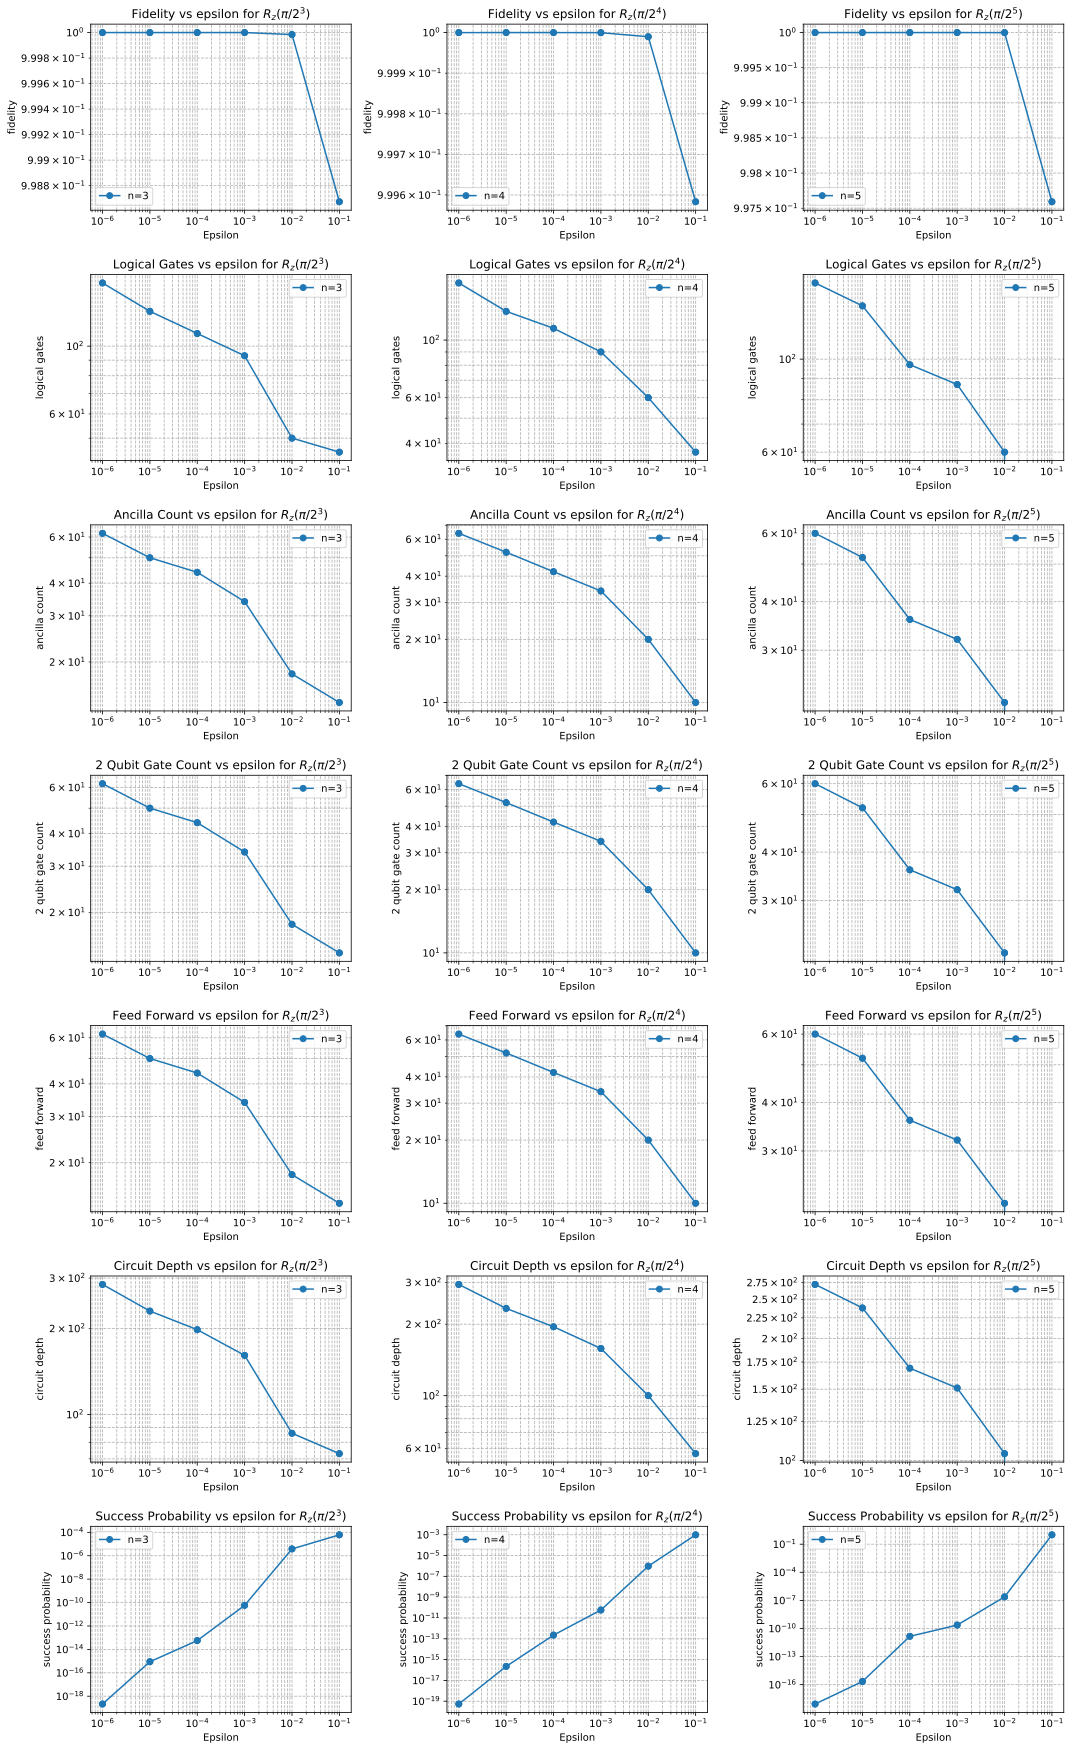

In [9]:
# PyGridSynth cost metrics vs epsilon
from utils import evaluate_synthesis_costs, density_matrix_fidelity

n_values = [3, 4, 5]
metrics = [
    "fidelity",
    "logical_gates",
    "ancilla_count",
    "2_qubit_gate_count",
    "feed_forward",
    "circuit_depth",
    "success_probability",
]
fig, axes = plt.subplots(len(metrics), len(n_values), figsize=(5 * len(n_values), 3.5 * len(metrics)))


@squin.kernel
def plus_reference():
    q = squin.qalloc(1)
    squin.h(q[0])
    return q

reference_sim = StackMemorySimulator(min_qubits=1)
reference_task = reference_sim.task(plus_reference)
reference_result = reference_task.run()
rho_reference = StackMemorySimulator.reduced_density_matrix(reference_result)

for j, n_val in enumerate(n_values):
    epsilons = [mpmath.mpf(f"1e-{int(k*0.1)}") for k in range(10, 70, 5)]  # Sweep from 1e-10 to 1e-60
    epsilon_values = [float(eps) for eps in epsilons]
    metric_series = {name: [] for name in metrics}

    for eps in epsilons:
        key = (n_val, str(eps))
        if key not in gridsynth_results:
            raise KeyError(f"Missing saved Gridsynth result for {key}")

        gates = gridsynth_results[key]

        @squin.kernel
        def synthesized_gate():
            q = squin.qalloc(1)
            ancilla = squin.qalloc(1)
            squin.h(q[0])
            squin.rz(-np.pi/(2**n_val), q[0])
            for gate in gates:
                if gate[0] == "H":
                    squin.h(q[0])
                elif gate[0] == "S":
                    squin.s(q[0])
                elif gate[0] == "T":
                    q = t_gate_teleportation(q, ancilla)
                elif gate[0] == "X":
                    squin.x(q[0])
                elif gate[0] == "Y":
                    squin.y(q[0])
                elif gate[0] == "Z":
                    squin.z(q[0])
                squin.reset(ancilla[0])  # Reset ancilla after each use
            return q

        sim = StackMemorySimulator(min_qubits=2)
        task = sim.task(synthesized_gate)
        res = task.run()
        state = StackMemorySimulator.reduced_density_matrix(res)

        fidelity = density_matrix_fidelity(rho_reference, state)

        costs = evaluate_synthesis_costs(gates)
        for name in metrics:
            if name == "success_probability":
                # Success probability = 1 / repeated_trials = 1 / 2^(t_count)
                metric_series[name].append(1.0 / costs["repeated_trials"])
            elif name == "fidelity":
                metric_series[name].append(fidelity)
            else:
                metric_series[name].append(costs[name])

    for i, name in enumerate(metrics):
        ax = axes[i, j]
        ax.plot(epsilon_values, metric_series[name], marker="o", label=f"n={n_val}")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Epsilon")
        ax.set_ylabel(name.replace("_", " "))
        ax.set_title(f"{name.replace('_', ' ').title()} vs epsilon for $R_z(\\pi/2^{{{n_val}}})$")
        ax.grid(True, which="both", ls="--")
        ax.legend()

plt.tight_layout()
plt.show()